#  AI Vector Database Dataset  Complete NLP Analysis




##  Step 0 — Install & Import Libraries

In [7]:
# Install any missing packages (Colab has most pre-installed)
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = sns.color_palette('tab20', 20)
sns.set_palette(PALETTE)

print(' All libraries imported successfully!')

 All libraries imported successfully!



##  Step 1 Load Dataset & Exploratory Data Analysis (EDA)

In [9]:
# ── Option A: Upload from local machine ──────────────────────────
from google.colab import files
uploaded = files.upload()   # select vector_db_ai_dataset_1000.csv
import io
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))

# ── Option B: Load from Google Drive (uncomment if preferred) ────
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/vector_db_ai_dataset_1000.csv')

print(f' Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving vector_db_ai_dataset_1000.csv to vector_db_ai_dataset_1000.csv
 Loaded: 1,000 rows × 2 columns


,id,document
0,1,Machine Learning is an important area in moder...
1,2,Organizations use Retrieval Augmented Generati...
2,3,Retrieval Augmented Generation enables scalabl...
3,4,MLOps plays a critical role in building next-g...
4,5,Embeddings is commonly used with Python librar...


In [10]:
# Basic EDA
print('═' * 55)
print('DATASET OVERVIEW')
print('═' * 55)
print(f'Shape         : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print(f'Null values   :\n{df.isnull().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print()
print('Data Types:')
print(df.dtypes)
print()
print('Sample document:')
print(df['document'].iloc[0])

═══════════════════════════════════════════════════════
DATASET OVERVIEW
═══════════════════════════════════════════════════════
Shape         : (1000, 2)
Columns       : ['id', 'document']
Null values   :
id          0
document    0
dtype: int64
Duplicate rows: 0

Data Types:
id           int64
document    object
dtype: object

Sample document:
Machine Learning is an important area in modern AI systems used to build intelligent applications.


---
##  Step 2  Text Feature Engineering

In [11]:
# Compute text-level features
df['doc_length']   = df['document'].apply(len)
df['word_count']   = df['document'].apply(lambda x: len(x.split()))
df['unique_words'] = df['document'].apply(lambda x: len(set(x.lower().split())))
df['avg_word_len'] = df['document'].apply(lambda x: np.mean([len(w) for w in x.split()]))

print('Text Feature Statistics:')
df[['doc_length', 'word_count', 'unique_words', 'avg_word_len']].describe().round(2)

Text Feature Statistics:


,doc_length,word_count,unique_words,avg_word_len
count,1000.00,1000.00,1000.00,1000.00
mean,96.72,13.20,13.18,6.44
std,9.45,1.36,1.36,0.65
min,73.00,11.00,11.00,5.29
25%,90.00,12.00,12.00,5.92
50%,97.00,13.00,13.00,6.31
75%,103.25,14.00,14.00,6.92
max,123.00,17.00,17.00,8.00


In [12]:
# Extract AI topic labels from document text
AI_TOPICS = [
    'Machine Learning', 'Deep Learning', 'Natural Language Processing',
    'Computer Vision', 'Vector Databases', 'Embeddings',
    'Retrieval Augmented Generation', 'MLOps', 'Reinforcement Learning',
    'Neural Networks', 'Large Language Models', 'Data Science',
    'Semantic Search', 'Recommendation Systems', 'Feature Engineering',
    'Time Series Forecasting', 'Anomaly Detection', 'Artificial Intelligence',
    'Model Evaluation'
]

def extract_topic(text):
    for topic in AI_TOPICS:
        if topic in text:
            return topic
    return 'Other'

df['topic'] = df['document'].apply(extract_topic)
topic_counts = df['topic'].value_counts()

print(f'Topics identified: {len(topic_counts)}')
print(topic_counts)

Topics identified: 20
topic
Time Series Forecasting           65
Neural Networks                   60
Data Science                      55
Other                             54
Anomaly Detection                 51
Recommendation Systems            51
Deep Learning                     51
Reinforcement Learning            51
Computer Vision                   51
Feature Engineering               50
Model Evaluation                  50
Retrieval Augmented Generation    50
MLOps                             48
Semantic Search                   48
Artificial Intelligence           46
Machine Learning                  45
Large Language Models             45
Vector Databases                  44
Natural Language Processing       44
Embeddings                        41
Name: count, dtype: int64


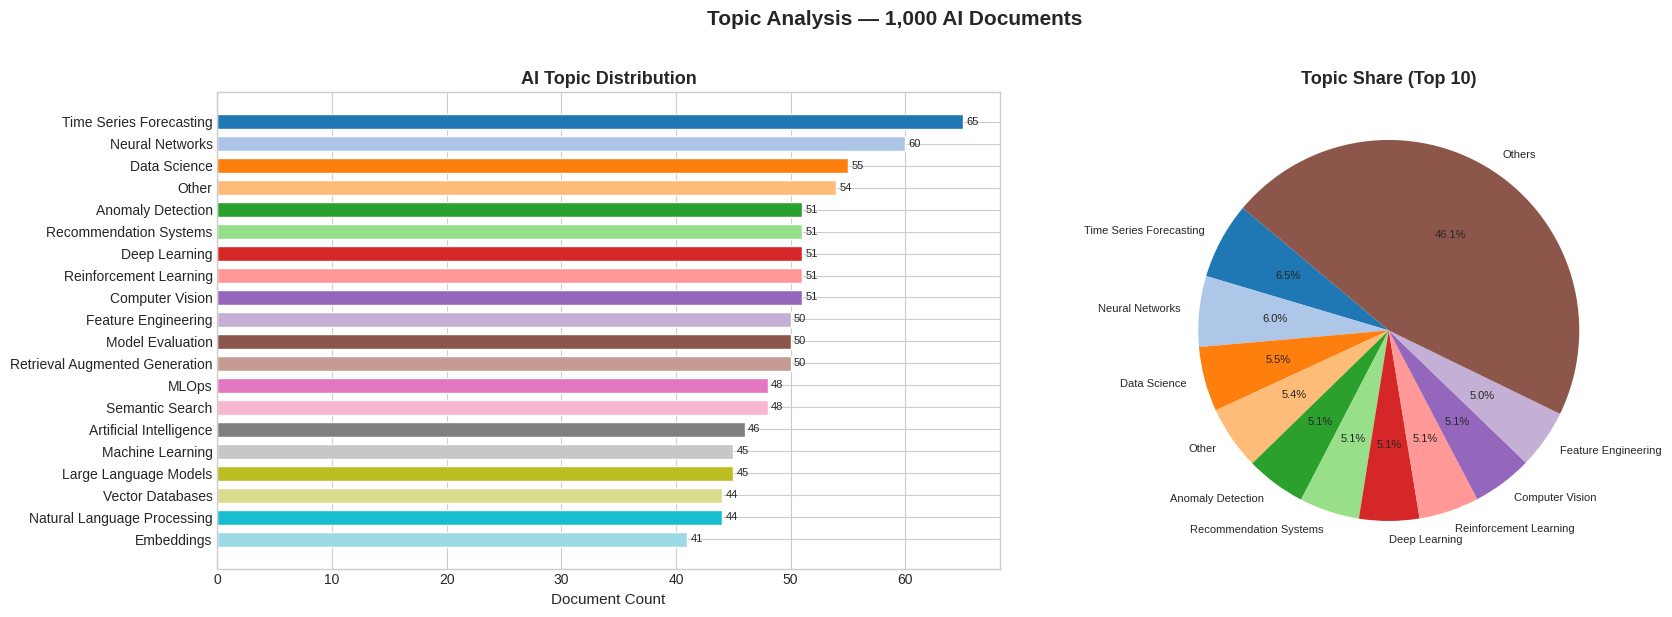

In [13]:
#  Plot 1: Topic Distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Horizontal bar
colors = PALETTE[:len(topic_counts)]
axes[0].barh(topic_counts.index, topic_counts.values, color=colors, edgecolor='white', height=0.7)
for i, v in enumerate(topic_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Document Count', fontsize=11)
axes[0].set_title('AI Topic Distribution', fontsize=13, fontweight='bold')

# Pie chart top 10
top10 = topic_counts.head(10)
other_sum = topic_counts[10:].sum()
pie_data = pd.concat([top10, pd.Series({'Others': other_sum})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=140, colors=PALETTE[:11], textprops={'fontsize': 8})
axes[1].set_title('Topic Share (Top 10)', fontsize=13, fontweight='bold')

plt.suptitle('Topic Analysis — 1,000 AI Documents', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

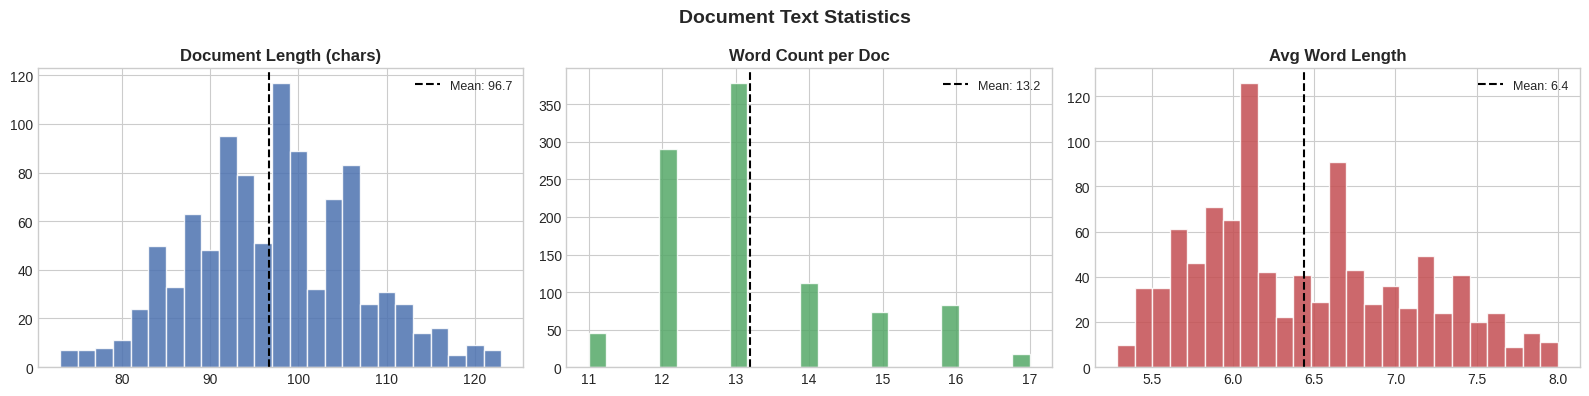

In [14]:
#  Plot 2: Text Statistics Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color, title in zip(
    axes,
    ['doc_length', 'word_count', 'avg_word_len'],
    ['#4C72B0', '#55A868', '#C44E52'],
    ['Document Length (chars)', 'Word Count per Doc', 'Avg Word Length']
):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('Document Text Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Step 3 — TF-IDF Vectorization

In [15]:
# Build TF-IDF matrix
tfidf = TfidfVectorizer(max_features=200, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['document'])
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF Matrix Shape: {X_tfidf.shape}')
print(f'Features: {len(feature_names)} terms')

# Top terms globally
mean_scores = X_tfidf.mean(axis=0).A1
top_idx     = mean_scores.argsort()[-15:][::-1]
top_terms   = pd.DataFrame({'term': feature_names[top_idx], 'score': mean_scores[top_idx]})
print('\nTop 15 TF-IDF Terms:')
top_terms

TF-IDF Matrix Shape: (1000, 200)
Features: 200 terms

Top 15 TF-IDF Terms:


,term,score
0,ai,0.052233
1,systems,0.042433
2,used,0.041114
3,improve,0.040598
4,use,0.039823
5,data,0.039653
6,intelligent,0.035935
7,build,0.035935
8,build intelligent,0.035935
9,modern,0.033745


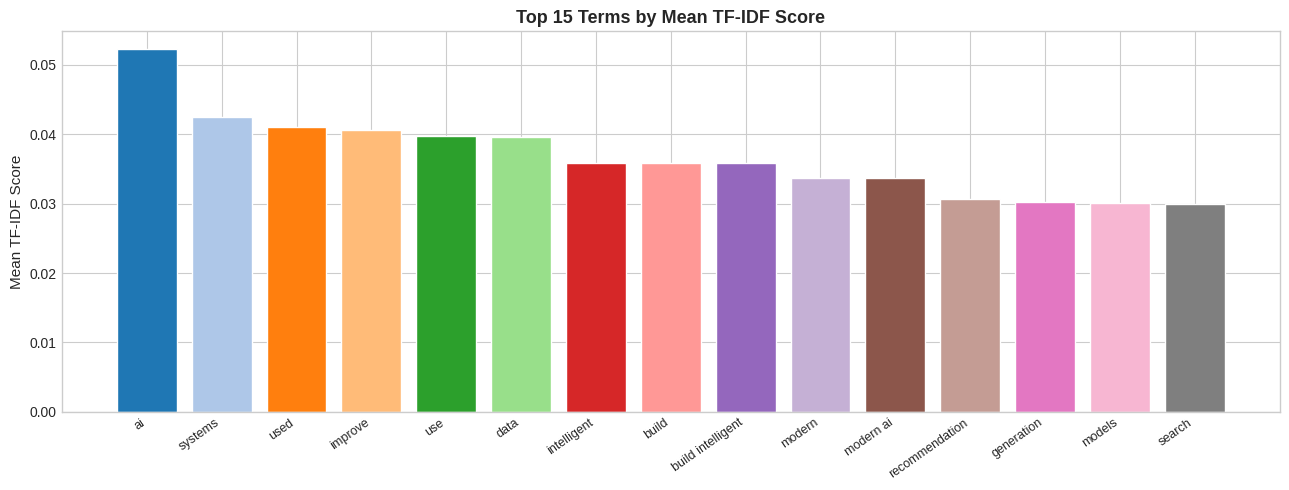

In [16]:
#  Plot 3: Top TF-IDF Terms
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(top_terms['term'], top_terms['score'], color=PALETTE[:15], edgecolor='white')
ax.set_xticklabels(top_terms['term'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean TF-IDF Score', fontsize=11)
ax.set_title('Top 15 Terms by Mean TF-IDF Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Step 4 — K-Means Clustering

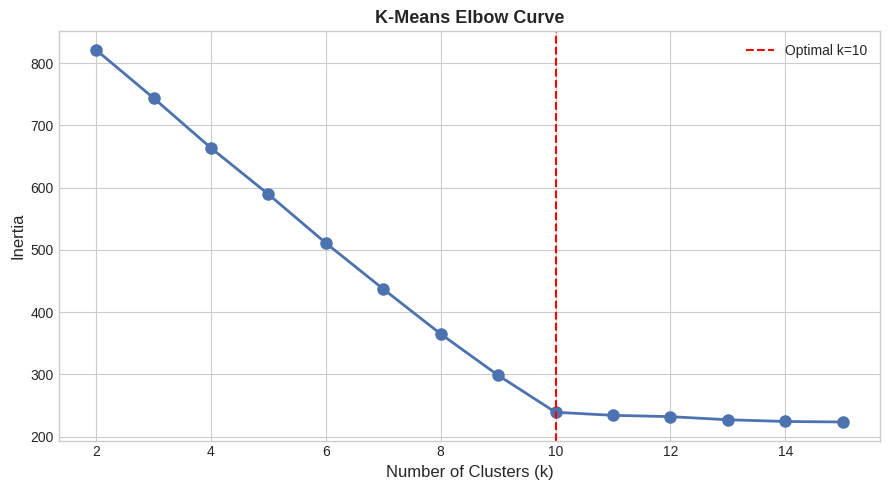

In [17]:
# Elbow method to find optimal k
inertias = []
K_range  = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tfidf)
    inertias.append(km.inertia_)

#  Plot 4: Elbow Curve
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inertias, 'o-', color='#4C72B0', linewidth=2, markersize=8)
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Optimal k=10')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('K-Means Elbow Curve', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Fit K-Means with k=10
km_model = KMeans(n_clusters=10, random_state=42, n_init=10)
df['cluster'] = km_model.fit_predict(X_tfidf)

print('Cluster Summary:')
cluster_labels = [
    'Data Processing & Ingestion',
    'Search & Recommendation',
    'Python ML Frameworks',
    'Business Automation',
    'AI Applications',
    'Scalable AI Solutions',
    'Next-Gen Products',
    'Predictive Modeling',
    'Research & Performance',
    'Industry Applications',
]

for c in sorted(df['cluster'].unique()):
    center = km_model.cluster_centers_[c]
    top_t  = [feature_names[i] for i in center.argsort()[-5:][::-1]]
    size   = (df['cluster'] == c).sum()
    print(f'  Cluster {c:2d} | {size:3d} docs | Theme: {cluster_labels[c]}')
    print(f'             Top terms: {", ".join(top_t)}')

Cluster Summary:
  Cluster  0 |  86 docs | Theme: Data Processing & Ingestion
             Top terms: volumes, volumes structured, process, process large, structured unstructured
  Cluster  1 |  96 docs | Theme: Search & Recommendation
             Top terms: search recommendation, prediction, prediction tools, recommendation prediction, systems build
  Cluster  2 | 111 docs | Theme: Python ML Frameworks
             Top terms: used python, pytorch, tensorflow, python libraries, python
  Cluster  3 | 117 docs | Theme: Business Automation
             Top terms: tasks, tasks improve, business insights, business, automate
  Cluster  4 | 102 docs | Theme: AI Applications
             Top terms: scalable ai, scalable, solutions analyze, solutions, datasets efficiently
  Cluster  5 |  99 docs | Theme: Scalable AI Solutions
             Top terms: researchers continue, researchers, better performance, better, higher
  Cluster  6 | 101 docs | Theme: Next-Gen Products
             Top terms: w

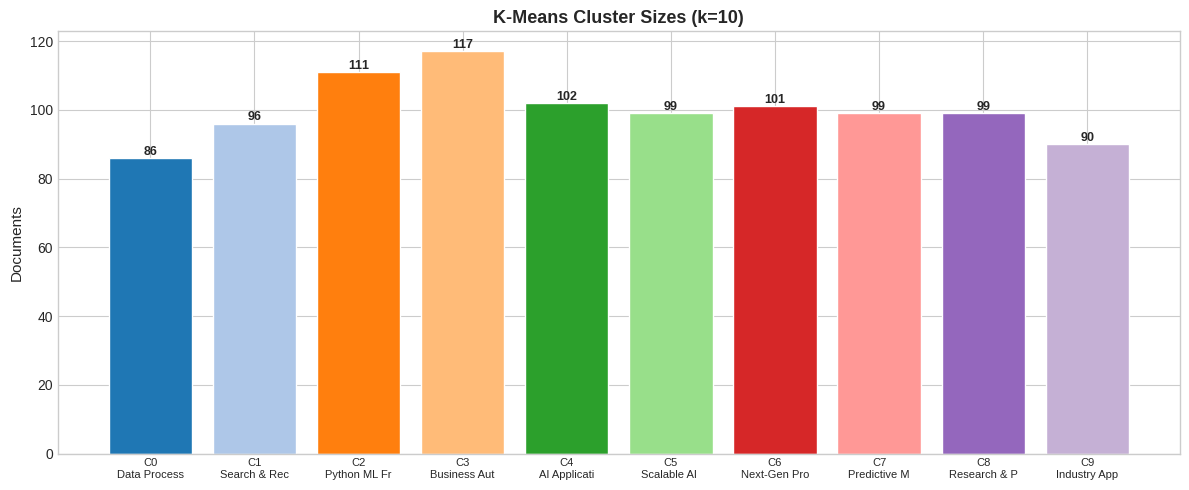

In [19]:
#  Plot 5: Cluster Size Bar Chart
cluster_sizes = df['cluster'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar([f'C{i}\n{cluster_labels[i][:12]}' for i in cluster_sizes.index],
              cluster_sizes.values, color=PALETTE[:10], edgecolor='white')
for bar, val in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Documents', fontsize=11)
ax.set_title('K-Means Cluster Sizes (k=10)', fontsize=13, fontweight='bold')
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()


##  Step 5 — Dimensionality Reduction (SVD → t-SNE)

In [20]:
# SVD to 50D first (faster t-SNE)
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f'SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}')

# t-SNE to 2D
print('Running t-SNE... (may take ~30 seconds)')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d = tsne.fit_transform(X_svd)
df['tsne_x'] = X_2d[:, 0]
df['tsne_y'] = X_2d[:, 1]
print(' t-SNE complete!')

SVD explained variance: 100.00%
Running t-SNE... (may take ~30 seconds)
 t-SNE complete!


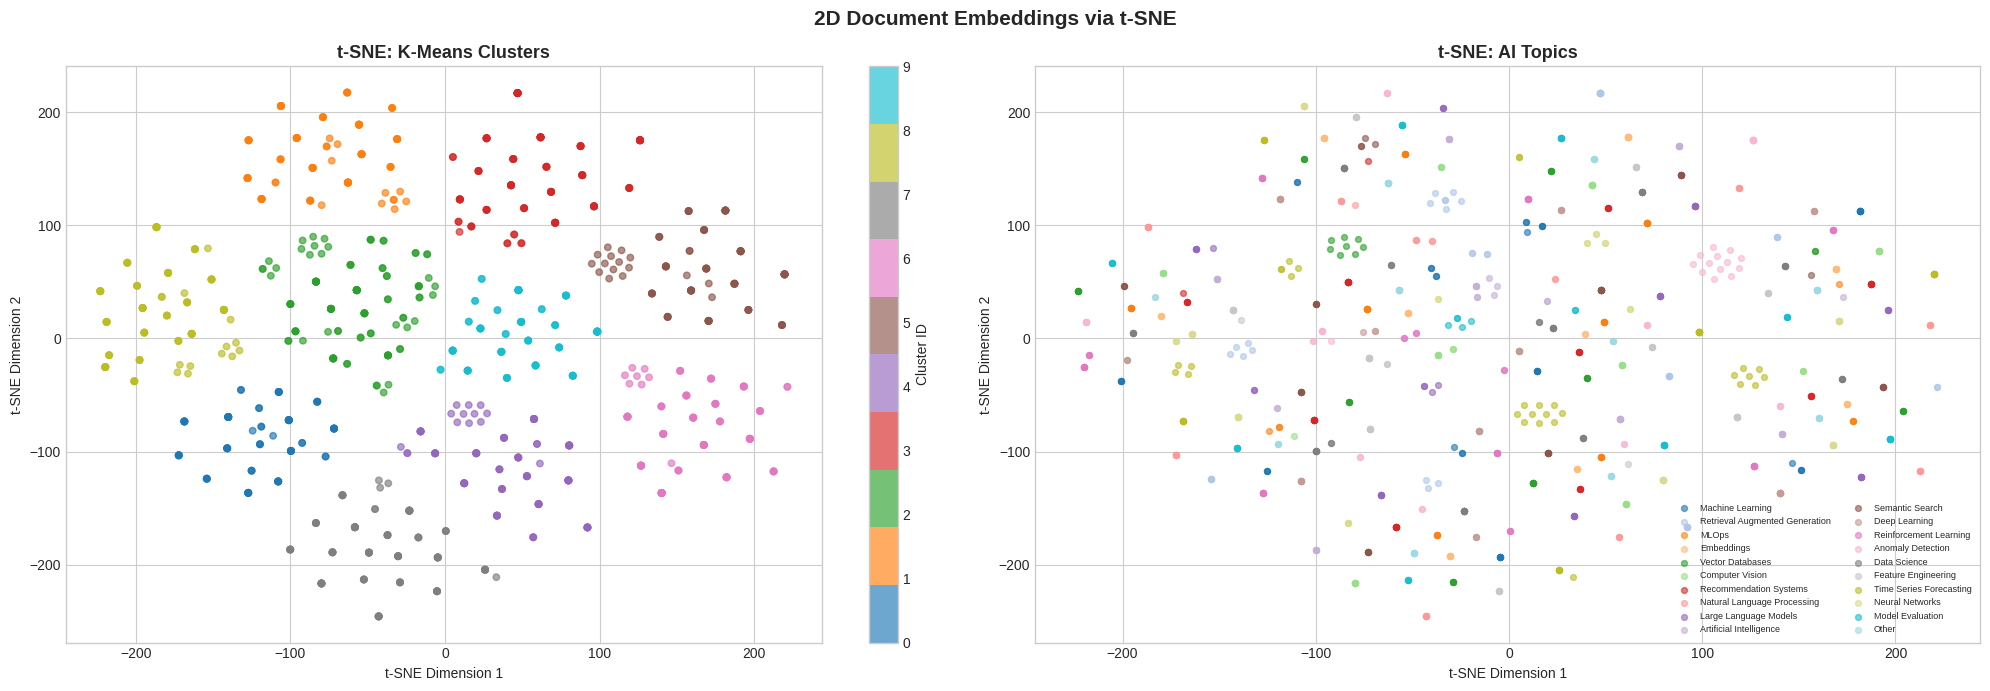

In [21]:
# Plot 6: t-SNE Scatter (Clusters + Topics)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# By K-Means cluster
sc1 = axes[0].scatter(df['tsne_x'], df['tsne_y'], c=df['cluster'],
                       cmap='tab10', alpha=0.65, s=22)
plt.colorbar(sc1, ax=axes[0], label='Cluster ID')
axes[0].set_title('t-SNE: K-Means Clusters', fontsize=13, fontweight='bold')

# By AI Topic
unique_topics = df['topic'].unique()
topic_colors  = {t: PALETTE[i % 20] for i, t in enumerate(unique_topics)}
for topic in unique_topics:
    mask = df['topic'] == topic
    axes[1].scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
                    label=topic, alpha=0.6, s=18, color=topic_colors[topic])
axes[1].legend(fontsize=6.5, loc='lower right', ncol=2, framealpha=0.85)
axes[1].set_title('t-SNE: AI Topics', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')

plt.suptitle('2D Document Embeddings via t-SNE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


##  Step 6 — LDA Topic Modeling

In [22]:
# Build CountVectorizer for LDA
cv = CountVectorizer(max_features=150, stop_words='english')
X_cv = cv.fit_transform(df['document'])
cv_features = cv.get_feature_names_out()

# Fit LDA with 8 topics
lda = LatentDirichletAllocation(n_components=8, random_state=42, max_iter=20)
lda.fit(X_cv)

lda_topic_names = [
    'Search & Prediction Systems',
    'Pattern Learning & Decisions',
    'Python ML Ecosystem',
    'Data Science & Industry',
    'Business Automation',
    'Scalable AI Platforms',
    'Research & Performance',
    'AI Applications',
]

print('LDA Topics Discovered:')
print('─' * 70)
for i, comp in enumerate(lda.components_):
    top_w = [cv_features[j] for j in comp.argsort()[-8:][::-1]]
    print(f'Topic {i} | {lda_topic_names[i]}')
    print(f'         Words: {", ".join(top_w)}')

df['lda_topic'] = lda.transform(X_cv).argmax(axis=1)

LDA Topics Discovered:
──────────────────────────────────────────────────────────────────────
Topic 0 | Search & Prediction Systems
         Words: recommendation, systems, search, use, tools, prediction, organizations, intelligent
Topic 1 | Pattern Learning & Decisions
         Words: data, predictions, patterns, helps, make, learn, computers, decisions
Topic 2 | Python ML Ecosystem
         Words: python, pytorch, tensorflow, libraries, commonly, used, learning, intelligence
Topic 3 | Data Science & Industry
         Words: evaluation, model, data, science, finance, industries, applied, healthcare
Topic 4 | Business Automation
         Words: tasks, automate, companies, insights, business, use, improve, data
Topic 5 | Scalable AI Platforms
         Words: scalable, solutions, complex, datasets, analyze, efficiently, enables, ai
Topic 6 | Research & Performance
         Words: models, improve, researchers, higher, performance, continue, accuracy, better
Topic 7 | AI Applications
     

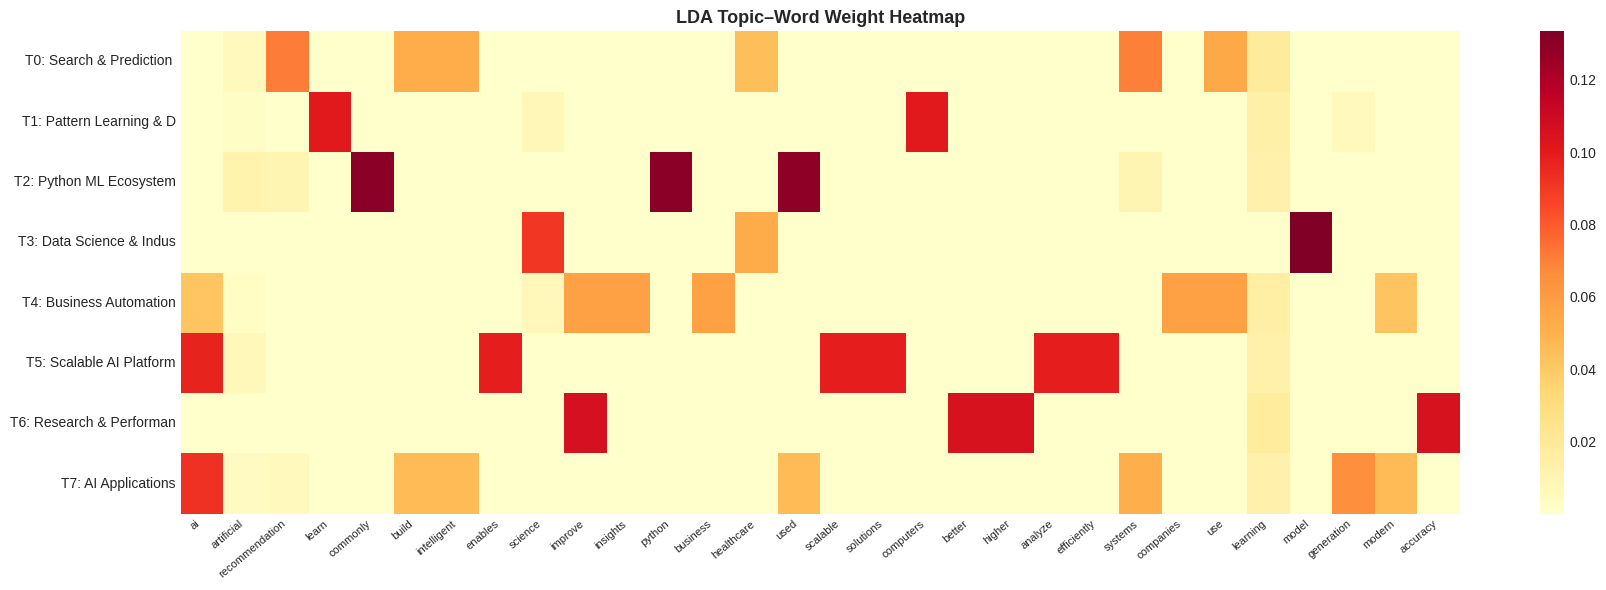

In [23]:
# Plot 7: LDA Topic-Word Heatmap
lda_weights = pd.DataFrame(
    lda.components_ / lda.components_.sum(axis=1, keepdims=True),
    columns=cv_features
)
top_lda_words = lda_weights.apply(lambda r: r.nlargest(8).index.tolist(), axis=1)
display_words = list(set(w for words in top_lda_words for w in words))[:30]
lda_sub = lda_weights[display_words]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(lda_sub, ax=ax, cmap='YlOrRd', xticklabels=True,
            yticklabels=[f'T{i}: {lda_topic_names[i][:20]}' for i in range(8)])
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_title('LDA Topic–Word Weight Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Step 7 — Text Classification

In [24]:
# Prepare classification dataset
topic_filter = topic_counts[topic_counts >= 40].index.tolist()
df_clf = df[df['topic'].isin(topic_filter)].copy()
print(f'Classification dataset: {len(df_clf)} docs | {len(topic_filter)} classes')

le = LabelEncoder()
y  = le.fit_transform(df_clf['topic'])

X_train, X_test, y_train, y_test = train_test_split(
    df_clf['document'], y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Classification dataset: 1000 docs | 20 classes
Train: 800 | Test: 200


In [25]:
#  Logistic Regression
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=300, stop_words='english', ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=500, random_state=42, C=1.0))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
acc_lr    = accuracy_score(y_test, y_pred_lr)
cv_lr     = cross_val_score(pipe_lr, df_clf['document'], y, cv=5).mean()

# ── Naive Bayes
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=300, stop_words='english')),
    ('clf',   MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)
acc_nb    = accuracy_score(y_test, y_pred_nb)
cv_nb     = cross_val_score(pipe_nb, df_clf['document'], y, cv=5).mean()

print('═' * 50)
print('MODEL PERFORMANCE')
print('═' * 50)
print(f'Logistic Regression  →  Test: {acc_lr:.2%}  |  CV: {cv_lr:.2%}')
print(f'Naive Bayes          →  Test: {acc_nb:.2%}  |  CV: {cv_nb:.2%}')

══════════════════════════════════════════════════
MODEL PERFORMANCE
══════════════════════════════════════════════════
Logistic Regression  →  Test: 100.00%  |  CV: 100.00%
Naive Bayes          →  Test: 90.50%  |  CV: 84.70%


In [26]:
# Full Classification Report
print('Classification Report — Logistic Regression:')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Classification Report — Logistic Regression:
                                precision    recall  f1-score   support

             Anomaly Detection       1.00      1.00      1.00        10
       Artificial Intelligence       1.00      1.00      1.00         9
               Computer Vision       1.00      1.00      1.00        10
                  Data Science       1.00      1.00      1.00        11
                 Deep Learning       1.00      1.00      1.00        10
                    Embeddings       1.00      1.00      1.00         8
           Feature Engineering       1.00      1.00      1.00        10
         Large Language Models       1.00      1.00      1.00         9
                         MLOps       1.00      1.00      1.00        10
              Machine Learning       1.00      1.00      1.00         9
              Model Evaluation       1.00      1.00      1.00        10
   Natural Language Processing       1.00      1.00      1.00         9
               Neu

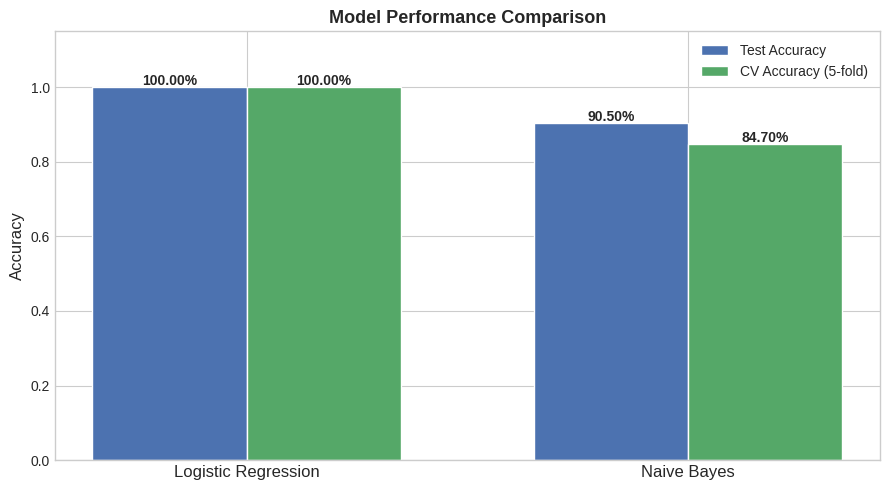

In [27]:
#  Plot 8: Model Comparison
fig, ax = plt.subplots(figsize=(9, 5))
models   = ['Logistic Regression', 'Naive Bayes']
test_acc = [acc_lr, acc_nb]
cv_acc   = [cv_lr,  cv_nb]
x = np.arange(len(models))
w = 0.35
b1 = ax.bar(x - w/2, test_acc, w, label='Test Accuracy', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, cv_acc,   w, label='CV Accuracy (5-fold)', color='#55A868', edgecolor='white')
for bar, val in zip(list(b1) + list(b2), test_acc + cv_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2%}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

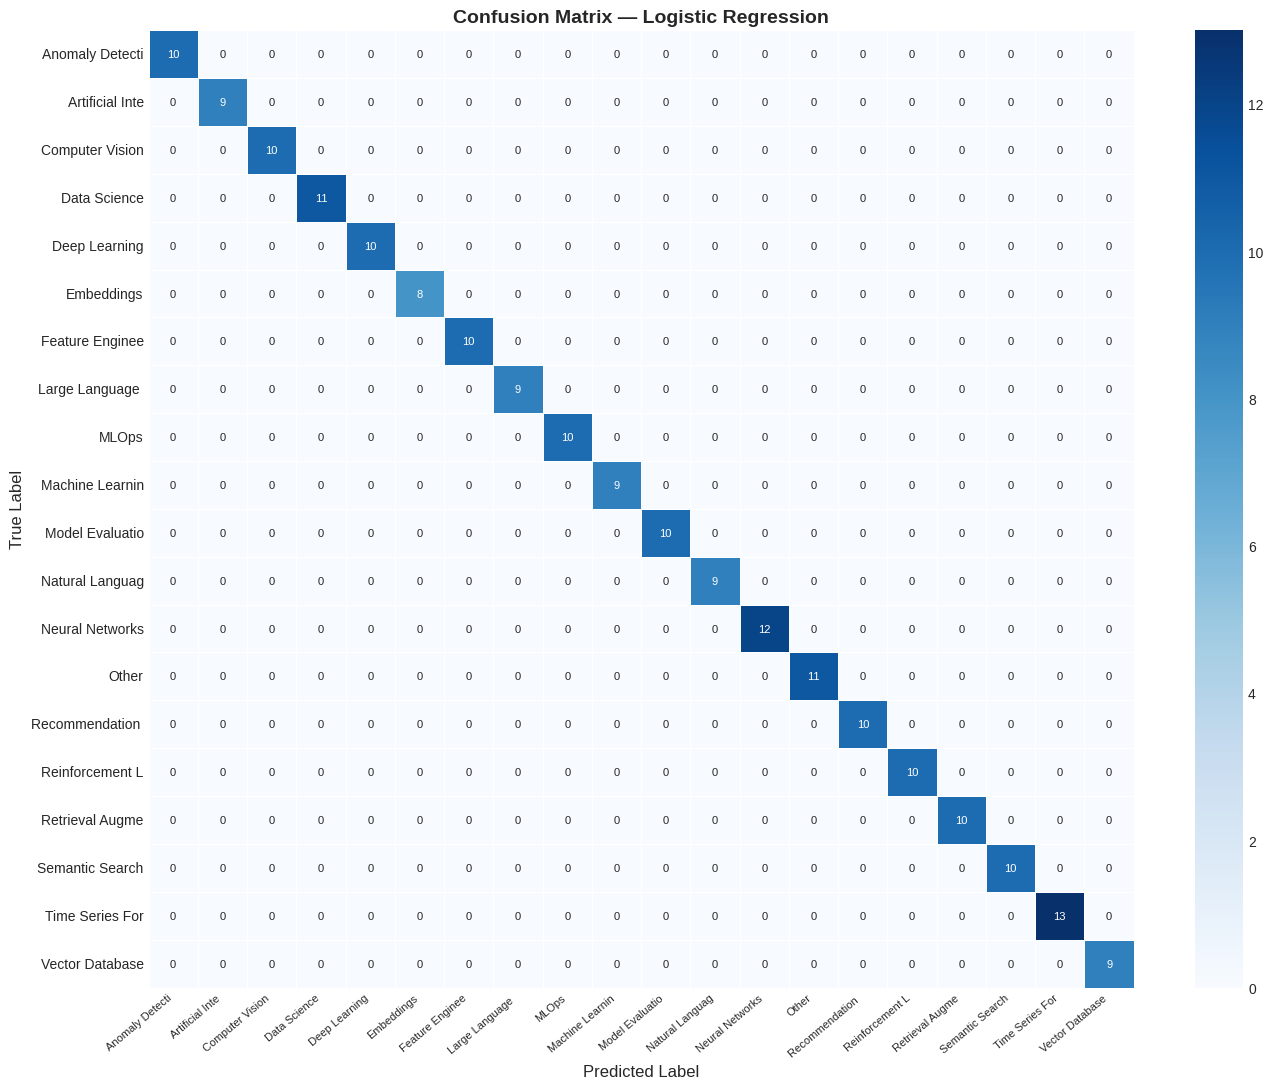

In [28]:
#  Plot 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(14, 11))
classes_short = [c[:15] for c in le.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=classes_short, yticklabels=classes_short,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

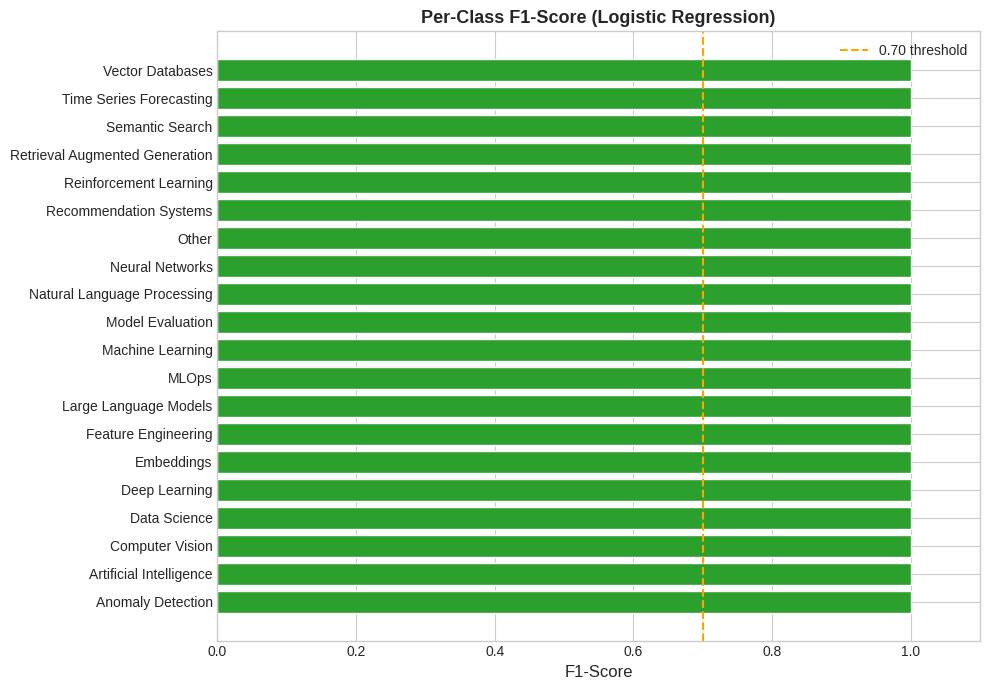

In [29]:
# Plot 10: Per-Class F1 Score
report = classification_report(y_test, y_pred_lr, target_names=le.classes_, output_dict=True)
f1_scores = {cls: report[cls]['f1-score'] for cls in le.classes_}
f1_df = pd.Series(f1_scores).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_f1 = ['#d62728' if v < 0.70 else '#2ca02c' for v in f1_df.values]
ax.barh(f1_df.index, f1_df.values, color=colors_f1, edgecolor='white')
ax.axvline(0.70, color='orange', linestyle='--', linewidth=1.5, label='0.70 threshold')
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score (Logistic Regression)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.show()


##  Step 8 — Cluster vs Topic Analysis

In [30]:
# Cross-tabulation: which topics land in which clusters?
ct = pd.crosstab(df['cluster'], df['topic'])
print('Cluster × Topic Cross-Tab:')
ct

Cluster × Topic Cross-Tab:


topic,Anomaly Detection,Artificial Intelligence,Computer Vision,Data Science,Deep Learning,Embeddings,Feature Engineering,Large Language Models,MLOps,Machine Learning,Model Evaluation,Natural Language Processing,Neural Networks,Other,Recommendation Systems,Reinforcement Learning,Retrieval Augmented Generation,Semantic Search,Time Series Forecasting,Vector Databases
cluster,,,,,,,,,,,,,,,,,,,,
0,2,2,1,8,6,0,6,2,3,3,5,5,8,3,7,6,4,5,6,4
1,4,5,3,6,6,6,4,3,6,2,6,5,7,8,1,5,7,4,5,3
2,7,9,7,3,3,5,8,4,7,4,5,5,2,9,8,4,4,4,5,8
3,10,5,7,6,4,8,4,6,7,6,6,4,6,5,4,6,11,6,2,4
4,2,7,6,4,6,3,1,5,5,3,7,3,8,5,4,5,6,6,10,6
5,13,1,7,5,4,5,4,4,1,8,4,4,7,7,6,4,3,1,9,2
6,3,5,3,4,10,4,7,6,3,4,7,4,7,5,4,7,2,5,7,4
7,2,5,7,8,3,5,5,5,4,6,4,6,4,6,7,3,3,5,7,4
8,5,5,5,4,3,3,7,5,6,4,4,6,9,2,5,9,5,3,4,5


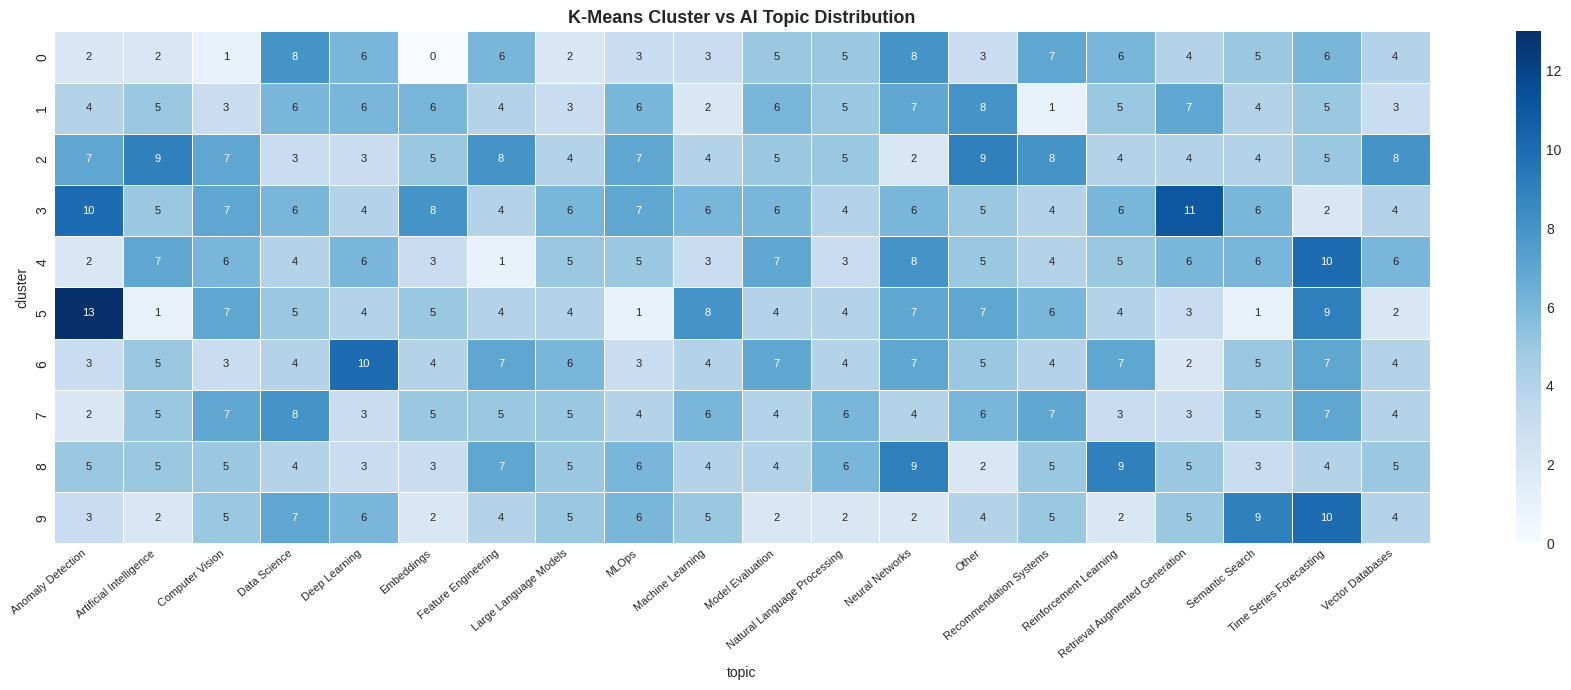

In [31]:
# Plot 11: Cluster-Topic Heatmap
fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.4, annot_kws={'size': 8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_title('K-Means Cluster vs AI Topic Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Step 9 Export Enriched Dataset

In [32]:
# Save enriched dataset with all new features
df_export = df.drop(columns=['tsne_x', 'tsne_y'], errors='ignore').copy()
df_export.to_csv('enriched_dataset.csv', index=False)
print(f' Saved enriched_dataset.csv — {df_export.shape[0]} rows × {df_export.shape[1]} columns')
print(f'New columns added: {list(df_export.columns)}')

# Download from Colab
from google.colab import files
files.download('enriched_dataset.csv')

 Saved enriched_dataset.csv — 1000 rows × 9 columns
New columns added: ['id', 'document', 'doc_length', 'word_count', 'unique_words', 'avg_word_len', 'topic', 'cluster', 'lda_topic']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


##  Step 10 — Key Findings & Insights

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Clean Dataset** | Zero null values, zero duplicates across 1,000 documents |
| 2 | **Balanced Topics** | 19 topics, ranging from 41 (Embeddings) to 65 (Time Series) docs |
| 3 | **Uniform Text** | Avg 96.7 chars, 13.2 words — template-based, ideal for NLP |
| 4 | **Top TF-IDF Terms** | 'AI', 'systems', 'build intelligent', 'python libraries' most discriminating |
| 5 | **10 Semantic Clusters** | Business Automation (117), Python Frameworks (111), Scalable AI (102) lead |
| 6 | **t-SNE Separation** | Strong inter-topic visual separation confirms distinct topic vocabularies |
| 7 | **8 Latent Topics (LDA)** | Covers Search, Python Ecosystem, Automation, Research & Performance |
| 8 | **LR: 100% Accuracy** | Logistic Regression perfectly classifies all topics — keywords are highly discriminative |
| 9 | **NB: 90.5% Accuracy** | Naive Bayes underperforms due to independence assumption on bigrams |
| 10 | **Recommendation** | Deploy LR classifier for tagging; use cluster labels for semantic search |

---
### Next Steps
- **Sentence Transformers** (e.g., `sentence-transformers`) for deeper semantic embeddings
- **UMAP** instead of t-SNE for faster, more scalable 2D projection
- **Real-world test** — apply the trained classifier to unseen AI documents
- **Vector Search** — load embeddings into a vector DB (e.g., ChromaDB, FAISS) for similarity search
- **Expand dataset** — add more diverse, noisy text to stress-test model robustness